# 04 · Market Structure: Revenue Mix, Probe-Card Competition, Supply Chain

1. Where does FormFactor's revenue come from, and how is the mix shifting?
2. How do segment margins differ?
3. How does FormFactor compare with its direct probe-card competitors on scale, growth and profitability?
4. Who are its suppliers and customers?

Market data is not available through a single API, so it was collected from 10-K/10-Q filings, earnings releases, foreign companies' reports and market research into `data/research/`. **Every row carries a `source` and `source_url`.**

| File | Content |
|---|---|
| `form_revenue_by_market.csv` | FormFactor revenue by market (Foundry & Logic, DRAM, Flash, Systems) |
| `segment_gross_margin.csv` | Gross profit and margin by segment (Probe Cards, Systems) |
| `probe_card_peers.csv` | Revenue and net income of probe-card makers in local currency |
| `fx_rates.csv` | IRS yearly average exchange rates |
| `market_facts.csv` | Market size, geography and customer concentration |
| `supply_chain.csv` | Suppliers, customers, competitors and demand drivers |

## Setup

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

BASE = Path.cwd()
RES_DIR = BASE / "data" / "research"
OUT_DIR = BASE / "data" / "analysis"
DB_PATH = BASE / "data" / "formfactor.db"

files = ["form_revenue_by_market", "segment_gross_margin", "probe_card_peers", "fx_rates", "market_facts", "supply_chain"]
data = {name: pd.read_csv(RES_DIR / f"{name}.csv") for name in files}

# Every manually collected value must be filled in and sourced
assert data["form_revenue_by_market"]["revenue_musd"].notna().all(), "missing market revenue"
for name, df in data.items():
    assert df["source"].notna().all(), f"unsourced rows in {name}"
pd.DataFrame({name: [len(df)] for name, df in data.items()}, index=["rows"])

,form_revenue_by_market,segment_gross_margin,probe_card_peers,fx_rates,market_facts,supply_chain
rows,28,12,8,20,21,13


In [2]:
conn = sqlite3.connect(DB_PATH)
def q(sql):
    return pd.read_sql_query(sql, conn)

tables = {"form_revenue_by_market": "market_revenue", "segment_gross_margin": "segment_margin",
          "probe_card_peers": "probe_peers", "fx_rates": "fx_rates",
          "market_facts": "market_facts", "supply_chain": "supply_chain"}
for csv_name, table in tables.items():
    data[csv_name].to_sql(table, conn, if_exists="replace", index=False)   # small reference tables: full reload
conn.commit()

## 1. Revenue mix

FormFactor sells probe cards (custom per chip design, used for wafer-level testing in production) and engineering systems (probe stations, thermal and cryogenic systems used mostly in R&D). Probe-card revenue is reported by the type of chip tested: Foundry & Logic, DRAM and Flash.

`SUM() OVER (PARTITION BY period)` supplies each period's total on every row, so shares are computed without collapsing the detail.

In [3]:
mix = q("""
SELECT period, market, revenue_musd,
       100.0 * revenue_musd / SUM(revenue_musd) OVER (PARTITION BY period) AS share_pct
FROM market_revenue
""")
order_p = [p for p in ["2022", "2023", "2024", "2025", "TTM 2026Q2"] if p in set(mix["period"])]
mix_wide = mix.pivot(index="market", columns="period", values="share_pct")[order_p].round(1)
mix_wide.loc[["Foundry & Logic", "DRAM", "Flash", "Systems"]]

period,2022,2023,2024,2025,TTM 2026Q2
market,,,,,
Foundry & Logic,54.70,54.80,49.90,47.10,46.30
DRAM,17.80,17.20,29.80,31.50,34.30
Flash,6.50,3.10,2.30,2.60,2.20
Systems,20.90,24.90,18.00,18.70,17.20


### 1.1 Cross-check: market totals vs. SEC-reported revenue

In [4]:
recon = q("""
WITH manual AS (
    SELECT CAST(period AS INTEGER) AS fiscal_year, SUM(revenue_musd) AS manual_total
    FROM market_revenue WHERE period_type = 'FY' GROUP BY period
)
SELECT m.fiscal_year,
       ROUND(m.manual_total, 1)                 AS sum_of_markets,
       ROUND(f.value / 1e6, 1)                  AS sec_revenue,
       ROUND(m.manual_total - f.value / 1e6, 2) AS difference
FROM manual m
JOIN financials f ON f.ticker = 'FORM' AND f.metric = 'revenue' AND f.fiscal_year = m.fiscal_year
ORDER BY m.fiscal_year
""")
assert recon["difference"].abs().max() < 1
recon

,fiscal_year,sum_of_markets,sec_revenue,difference
0,2022,747.90,747.90,0.00
1,2023,663.10,663.10,0.00
2,2024,763.60,763.60,0.00
3,2025,785.00,785.00,0.01


### 1.2 Downturn sensitivity: FY2022 → FY2023 by market (self-join)

In [5]:
q("""
SELECT a.market,
       ROUND(a.revenue_musd, 1) AS fy2022,
       ROUND(b.revenue_musd, 1) AS fy2023,
       ROUND(100.0 * (b.revenue_musd - a.revenue_musd) / a.revenue_musd, 1) AS change_pct
FROM market_revenue a
JOIN market_revenue b ON a.market = b.market
WHERE a.period = '2022' AND b.period = '2023'
ORDER BY change_pct
""")

,market,fy2022,fy2023,change_pct
0,Flash,48.80,20.60,-57.80
1,DRAM,133.40,113.80,-14.70
2,Foundry & Logic,409.20,363.50,-11.20
3,Systems,156.50,165.20,5.50


Systems revenue includes the Metrology (FRT) business sold in Q4 2023 ($29.0M in 2022, $21.2M in 2023). Excluding it, Systems grew about 13% in 2023 while every probe-card market declined.

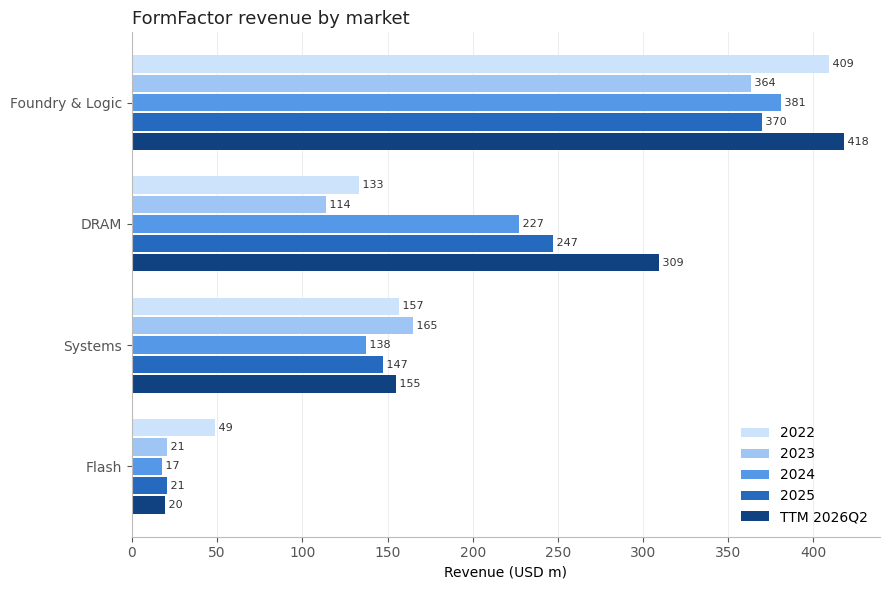

In [6]:
import matplotlib.pyplot as plt

def style(ax):
    """Minimal chart style: no top/right spines, light axes, gridlines behind data."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#bbbbbb")
    ax.set_axisbelow(True)
    ax.tick_params(colors="#555555")

markets = ["Foundry & Logic", "DRAM", "Systems", "Flash"]
shades = ["#cde2fb", "#9ec5f4", "#5598e7", "#256abf", "#104281"]   # light → dark = older → newer
n = len(order_p)
bar_h = 0.8 / n

fig, ax = plt.subplots(figsize=(9, 6))
for i, p in enumerate(order_p):
    d = mix[mix["period"] == p].set_index("market").reindex(markets)["revenue_musd"]
    ys = [y + (i - (n - 1) / 2) * bar_h for y in range(len(markets))]
    ax.barh(ys, d.values, height=bar_h * 0.9, color=shades[i], label=p)
    for y, v in zip(ys, d.values):
        ax.text(v, y, f" {v:.0f}", va="center", fontsize=8, color="#333333")
ax.set_yticks(range(len(markets)))
ax.set_yticklabels(markets)
ax.invert_yaxis()
ax.set_xlabel("Revenue (USD m)")
ax.set_title("FormFactor revenue by market", loc="left", fontsize=13, color="#222222")
ax.grid(axis="x", color="#eeeeee")
ax.legend(frameon=False, loc="lower right")
style(ax)
plt.tight_layout()
plt.savefig(OUT_DIR / "form_revenue_by_market.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Segment gross margins

In [7]:
q("""
SELECT segment, fiscal_year, revenue_musd, gross_profit_musd, gross_margin_pct
FROM segment_margin
WHERE segment != 'Corporate and Other'
""").pivot(index="segment", columns="fiscal_year", values="gross_margin_pct")

fiscal_year,2022,2023,2024,2025
segment,,,,
Probe Cards,39.80,37.20,41.40,40.50
Systems,51.70,51.30,43.20,41.80


- **Probe Cards** gross margin has stayed around 40% (39.8% → 37.2% → 41.4% → 40.5%) despite revenue growing from $498M (2023) to $638M (2025).
- Management attributes the 2025 decline to higher manufacturing costs, **including tariffs**, partly offset by mix and utilization, and states that *"in general, our DRAM products have lower margins than our Foundry & Logic products."* DRAM rose from 36.3% to 38.8% of probe-card sales in 2025, so the fastest-growing market is margin-dilutive.
- **Systems** margin fell from ~51% to ~42% after the FRT divestiture, so it no longer lifts the company average.

## 3. Probe-card competitors in USD

Revenues are converted with IRS yearly average rates, joined on both currency and year.

In [8]:
conn.execute("DROP VIEW IF EXISTS probe_peers_usd")
conn.execute("""
CREATE VIEW probe_peers_usd AS
SELECT p.company, p.country, p.fiscal_year, p.currency, p.revenue_local_m,
       p.revenue_local_m / x.units_per_usd    AS revenue_usd_m,
       p.net_income_local_m / x.units_per_usd AS net_income_usd_m,
       p.revenue_scope
FROM probe_peers p
JOIN fx_rates x ON p.currency = x.currency AND p.fiscal_year = x.year
""")
growth = q("""
SELECT company, fiscal_year,
       ROUND(revenue_usd_m, 1) AS revenue_usd_m,
       ROUND(100.0 * (revenue_local_m - LAG(revenue_local_m) OVER w) / LAG(revenue_local_m) OVER w, 1) AS growth_local_pct,
       ROUND(100.0 * (revenue_usd_m   - LAG(revenue_usd_m)   OVER w) / LAG(revenue_usd_m)   OVER w, 1) AS growth_usd_pct
FROM probe_peers_usd
WINDOW w AS (PARTITION BY company ORDER BY fiscal_year)
""")
growth["fx_effect_pct"] = (growth["growth_usd_pct"] - growth["growth_local_pct"]).round(1)
growth = growth.dropna()          # 2025 vs 2024
growth.sort_values("growth_local_pct", ascending=False)

,company,fiscal_year,revenue_usd_m,growth_local_pct,growth_usd_pct,fx_effect_pct
1,Chunghwa Precision Test,2025,154.20,33.30,37.40,4.10
5,Micronics Japan,2025,469.00,26.10,27.60,1.50
7,Technoprobe,2025,709.30,15.70,20.60,4.90
3,FormFactor,2025,637.90,1.90,1.90,0.00


Chunghwa Precision Test's 2024 revenue is estimated from its reported 2025 revenue and 33.3% growth, so its growth rate is not independent evidence.

## 4. Market share and concentration

Two approaches, used as a cross-check:
- **Top-down:** company revenue ÷ estimated market size. Mordor Intelligence puts the 2026 market at $3.04B growing 9.35% a year, implying roughly **$2.78B in 2025** (an estimate).
- **Bottom-up:** each company's share of the four listed makers' combined revenue.

In [9]:
mkt_2026 = q("SELECT value FROM market_facts WHERE item = 'Global probe card market' AND year = 2026")["value"].iloc[0]
cagr = q("SELECT value FROM market_facts WHERE item LIKE '%CAGR%'")["value"].iloc[0]
mkt_2025 = mkt_2026 / (1 + cagr / 100) * 1000

share = q(f"""
SELECT company, fiscal_year,
       ROUND(revenue_usd_m, 1)                                                              AS revenue_usd_m,
       CASE WHEN fiscal_year = 2025 THEN ROUND(100.0 * revenue_usd_m / {mkt_2025}, 1) END   AS share_of_market_pct,
       ROUND(100.0 * revenue_usd_m / SUM(revenue_usd_m) OVER (PARTITION BY fiscal_year), 1) AS share_of_group_pct,
       RANK() OVER (PARTITION BY fiscal_year ORDER BY revenue_usd_m DESC)                   AS rank_in_year
FROM probe_peers_usd
ORDER BY fiscal_year DESC, revenue_usd_m DESC
""")
share

,company,fiscal_year,revenue_usd_m,share_of_market_pct,share_of_group_pct,rank_in_year
0,Technoprobe,2025,709.30,25.50,36.00,1
1,FormFactor,2025,637.90,22.90,32.40,2
2,Micronics Japan,2025,469.00,16.90,23.80,3
3,Chunghwa Precision Test,2025,154.20,5.50,7.80,4
4,FormFactor,2024,626.00,NaN,37.00,1
5,Technoprobe,2024,587.90,NaN,34.70,2
6,Micronics Japan,2024,367.60,NaN,21.70,3
7,Chunghwa Precision Test,2024,112.20,NaN,6.60,4


In [10]:
# Herfindahl-Hirschman Index within the four listed makers (>1,800 = highly concentrated)
q("""
WITH s AS (
    SELECT fiscal_year, 100.0 * revenue_usd_m / SUM(revenue_usd_m) OVER (PARTITION BY fiscal_year) AS share_pct
    FROM probe_peers_usd
)
SELECT fiscal_year, ROUND(SUM(share_pct * share_pct), 0) AS hhi_within_group
FROM s GROUP BY fiscal_year ORDER BY fiscal_year
""")

,fiscal_year,hhi_within_group
0,2024,"3,086.00"
1,2025,"2,972.00"


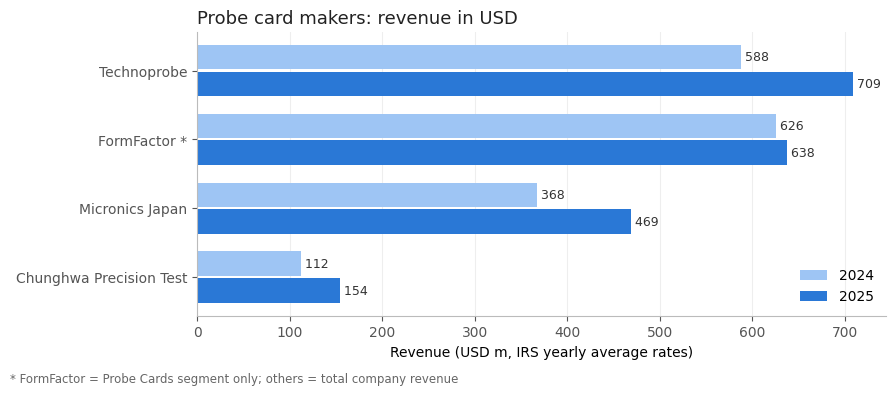

In [11]:
pv = q("SELECT company, fiscal_year, revenue_usd_m FROM probe_peers_usd").pivot(
    index="company", columns="fiscal_year", values="revenue_usd_m")
pv = pv.sort_values(pv.columns.max(), ascending=False)
years = list(pv.columns)
year_colors = {years[0]: "#9ec5f4", years[-1]: "#2a78d6"}

fig, ax = plt.subplots(figsize=(9, 3.8))
bar_h = 0.36
for i, yr in enumerate(years):
    ys = [y + (i - 0.5) * (bar_h + 0.03) for y in range(len(pv))]
    ax.barh(ys, pv[yr].values, height=bar_h, color=year_colors[yr], label=str(yr))
    for y, v in zip(ys, pv[yr].values):
        ax.text(v, y, f" {v:.0f}", va="center", fontsize=9, color="#333333")
ax.set_yticks(range(len(pv)))
ax.set_yticklabels([f"{c} *" if c == "FormFactor" else c for c in pv.index])
ax.invert_yaxis()
ax.set_xlabel("Revenue (USD m, IRS yearly average rates)")
ax.set_title("Probe card makers: revenue in USD", loc="left", fontsize=13, color="#222222")
ax.grid(axis="x", color="#eeeeee")
ax.legend(frameon=False, loc="lower right")
style(ax)
fig.text(0.01, -0.02, "* FormFactor = Probe Cards segment only; others = total company revenue", fontsize=8.5, color="#666666")
plt.tight_layout()
plt.savefig(OUT_DIR / "probe_card_revenue_usd.png", dpi=150, bbox_inches="tight")
plt.show()

Revenue scopes differ: FormFactor's figure is its Probe Cards segment only, while the others are total company revenue (Technoprobe includes the Device Interface Solutions business acquired from Teradyne). Competitors' pure probe-card revenue is therefore somewhat lower than shown.

## 5. Profitability vs. probe-card competitors

`UNION ALL` stacks FormFactor (SEC data) and competitors (manually collected) in one result. All figures are total company.

In [12]:
prof = q("""
SELECT 'FormFactor' AS company, fiscal_year,
       ROUND(revenue / 1e6, 1) AS revenue_usd_m, ROUND(net_income / 1e6, 1) AS net_income_usd_m,
       ROUND(100.0 * net_income / revenue, 1) AS net_margin_pct
FROM fin_wide WHERE ticker = 'FORM' AND fiscal_year IN (2024, 2025)
UNION ALL
SELECT company, fiscal_year, ROUND(revenue_usd_m, 1), ROUND(net_income_usd_m, 1),
       ROUND(100.0 * net_income_usd_m / revenue_usd_m, 1)
FROM probe_peers_usd WHERE net_income_usd_m IS NOT NULL
ORDER BY fiscal_year DESC, net_margin_pct DESC
""")
prof

,company,fiscal_year,revenue_usd_m,net_income_usd_m,net_margin_pct
0,Micronics Japan,2025,469.00,80.60,17.20
1,Technoprobe,2025,709.30,111.50,15.70
2,FormFactor,2025,785.00,54.40,6.90
3,Micronics Japan,2024,367.60,58.20,15.80
4,Technoprobe,2024,587.90,68.00,11.60
5,FormFactor,2024,763.60,69.60,9.10


Operating-level checks rule out non-operating income as the explanation:
- **Micronics Japan:** operating income ¥16.5B on sales of ¥70.2B, a **23.6% operating margin** in 2025 (22.6% in 2024); ordinary income was only ¥0.6B higher.
- **Technoprobe:** 2025 EBITDA margin of **32.1%**.
- **FormFactor:** 7.3% operating margin in 2025, with a ~40% probe-card gross margin.

The margin gap is in the core probe-card business, not a structural feature of the industry.

## 6. Supply chain

In [13]:
q("SELECT tier, role, name, detail FROM supply_chain")

,tier,role,name,detail
0,Upstream,Materials & components,Ceramic and organic substrates,Sole or limited source; purchase orders rather than long-term contracts
1,Upstream,Materials & components,Complex printed circuit boards,Sole or limited source; some minimum order quantities
2,Upstream,Materials & components,Contact elements and interconnects,Sole or limited source
3,Company,Probe card manufacturing,FormFactor - Livermore CA & Beaverton OR,Primary probe card facilities
4,Company,Systems manufacturing,FormFactor - Boulder CO; Thiendorf / Munich / Karlsruhe Germany,"Probe stations, thermal and cryogenic systems"
5,Competitor,Probe cards,Technoprobe; Micronics Japan; Japan Electronic Materials; MPI; Korea Instrum...,Named probe card competitors
6,Competitor,Probe stations,MPI; Semishare; STAr Technologies; Tokyo Electron; Wentworth Laboratories,Named systems competitors
7,Downstream,Customer (DRAM / HBM),SK hynix,Largest customer in FY2025 (about 22.9% of revenue)
8,Downstream,Customer (Foundry & Logic),Intel,Over 10% of revenue in parts of 2024-2025
9,Downstream,Customer (Foundry),TSMC,Over 10% of revenue in at least one 2025 quarter


In [14]:
q("SELECT topic, item, year, value, unit, source FROM market_facts WHERE topic IN ('geography', 'customers', 'outlook') ORDER BY topic, item, year")

,topic,item,year,value,unit,source
0,customers,FORM largest single customer share of revenue,2025,22.90,%,FORM FY2025 10-K (largest customer; SK hynix per quarterly customer table)
1,customers,Intel share of FORM revenue (six months),2022,20.90,%,FORM 10-Q six months ended 2023-07-01 (prior-year column)
2,customers,Intel share of FORM revenue (six months),2023,17.20,%,FORM 10-Q six months ended 2023-07-01
3,geography,FORM China share of revenue,2023,14.00,%,FORM FY2025 10-K
4,geography,FORM China share of revenue,2024,14.00,%,FORM FY2025 10-K
5,geography,FORM China share of revenue,2025,7.00,%,FORM FY2025 10-K
6,geography,FORM international share of revenue,2023,74.00,%,FORM FY2025 10-K
7,geography,FORM international share of revenue,2024,76.00,%,FORM FY2025 10-K
8,geography,FORM international share of revenue,2025,81.00,%,FORM FY2025 10-K
9,outlook,FORM FY2025 non-GAAP gross margin,2025,40.80,%,FORM Q4 2025 earnings release


## Export

In [15]:
mix.to_csv(OUT_DIR / "form_revenue_mix.csv", index=False)
share.to_csv(OUT_DIR / "probe_card_market_share.csv", index=False)
growth.to_csv(OUT_DIR / "probe_card_growth.csv", index=False)
conn.close()

## Findings

**Revenue mix is shifting toward DRAM / HBM.** DRAM grew from $114M (17.2% of revenue) in 2023 to $309M (34.3%) in the twelve months to June 2026, driven by high-bandwidth memory for AI accelerators, where each stacked die must be tested at wafer level. Flash fell from $49M to about $20M. Systems acted as a buffer in the downturn.

**Growth is not converting into margin.** Probe-card gross margin is flat at ~40%, DRAM carries lower margins than Foundry & Logic, and tariffs raised manufacturing costs in 2025. Systems margin dropped ~10 points after the FRT sale.

**FormFactor is losing share.** In USD, Technoprobe's revenue ($709M) overtook FormFactor's probe-card segment ($638M) in 2025. In local currency FormFactor grew 1.9% versus 15.7% (Technoprobe), 26.1% (Micronics Japan) and 33.3% (Chunghwa Precision Test). FormFactor's share of the four listed makers fell from 37.0% to 32.4%; its estimated global share is about 23%.

**Competitors are far more profitable.** Micronics Japan's 23.6% operating margin and Technoprobe's 32.1% EBITDA margin compare with FormFactor's 7.3% operating margin.

**Supply-chain position.** Key inputs (ceramic and organic substrates, PCBs, contact elements) are sole- or limited-source on purchase orders; customers are a handful of the largest chipmakers, with the largest accounting for 22.9% of 2025 revenue. Manufacturing is in the U.S. while 81% of revenue is international, exposing FormFactor to tariffs. China fell from 14% to 7% of revenue in 2025 under export restrictions.

**Implications.** The investment case depends on (1) whether the guided recovery in gross margin (45% non-GAAP for Q1 2026 vs. 40.8% for FY2025) proves durable as new capacity fills; (2) winning share in HBM without further margin dilution; (3) new growth vectors in co-packaged optics (Keystone Photonics acquisition) and cryogenic test; and (4) supply and tariff resilience.